In [1]:
from google.colab import drive
drive.mount('/content/drive')

%cd "/content/drive/MyDrive/8vo/data/Flowers"
!pwd
# Imports
import matplotlib.pyplot as plt
import numpy as np
import os
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Conv2D, Flatten, MaxPooling2D, GlobalAveragePooling2D, Dropout
import json

Mounted at /content/drive
/content/drive/MyDrive/8vo/data/Flowers
/content/drive/MyDrive/8vo/data/Flowers


In [5]:
train_dir = '/content/drive/MyDrive/8vo/data/Flowers/train'
class_names = sorted(os.listdir(train_dir))
print(class_names)

['astilbe', 'bellflower', 'black_eyed_susan', 'calendula', 'california_poppy', 'carnation', 'common_daisy', 'coreopsis', 'dandelion', 'iris', 'rose', 'sunflower', 'tulip', 'water_lily']


In [2]:
bettermodel = tf.keras.models.load_model('BeSTFlorANKModel.h5')


In [3]:
def predict_folder_like_testds(folder_path, model, class_names):

    image_files = [
        f for f in os.listdir(folder_path)
        if f.lower().endswith((".jpg", ".jpeg", ".png"))
    ]

    print(f"Found image files in {folder_path}: {image_files}")

    for file in image_files:
        img_path = os.path.join(folder_path, file)

        img = tf.keras.utils.load_img(
            img_path,
            target_size=(256, 256)
        )
        img = tf.keras.utils.img_to_array(img)
        img_norm = img / 255.0

        pred = model.predict(
            tf.expand_dims(img_norm, axis=0),
            verbose=0
        )

        pred_label = class_names[np.argmax(pred)]
        confidence = np.max(pred) * 100

        plt.figure(figsize=(5, 5))
        plt.imshow(img.astype("uint8"))
        plt.axis('off')
        plt.title(
            f"{file}\nPredicción: {pred_label} ({confidence:.1f}%)",
            fontsize=13
        )
        plt.tight_layout()
        plt.show()

input_folder = "/content/drive/MyDrive/8vo/data/Flowers/usage"
output_folder = "/content/drive/MyDrive/8vo/data/Flowers/usage"

os.makedirs(output_folder, exist_ok=True)

for file in os.listdir(input_folder):
    if file.lower().endswith((".jpg", ".jpeg", ".png")):
        img_path = os.path.join(input_folder, file)

        img = tf.keras.utils.load_img(
            img_path,
            target_size=(256, 256)
        )

        save_path = os.path.join(output_folder, file)
        #img = tf.image.rot90(img, k=3)
        tf.keras.utils.save_img(save_path, img)

print("Todas las imágenes fueron forzadas a 256x256 y guardadas.")

Todas las imágenes fueron forzadas a 256x256 y guardadas.


Checking folder: /content/drive/MyDrive/8vo/data/Flowers/usage
All files found in /content/drive/MyDrive/8vo/data/Flowers/usage: ['ivan-jevtic-p7mo8-CG5Gs-unsplash-2-scaled.jpg', 'pngtree-realistic-red-rose-white-background-png-image_11716749.png', "Rosa_'Ambiente',_Bad_Wörishofen,_Alemania,_2019-06-20,_DD_25.jpg", '2024-08-20_14_33_27_Fully_open_American_White_Water_Lily_flower_and_leaves_in_a_shallow_cove_of_Success_Lake_within_the_Colliers_Mills_Wildlife_Management_Area_in_Jackson_Township,_Ocean_County,_New_Jersey.jpg', '61PVeHfdbvL._AC_UF894,1000_QL80_.jpg']
Found image files in /content/drive/MyDrive/8vo/data/Flowers/usage: ['ivan-jevtic-p7mo8-CG5Gs-unsplash-2-scaled.jpg', 'pngtree-realistic-red-rose-white-background-png-image_11716749.png', "Rosa_'Ambiente',_Bad_Wörishofen,_Alemania,_2019-06-20,_DD_25.jpg", '2024-08-20_14_33_27_Fully_open_American_White_Water_Lily_flower_and_leaves_in_a_shallow_cove_of_Success_Lake_within_the_Colliers_Mills_Wildlife_Management_Area_in_Jackson_

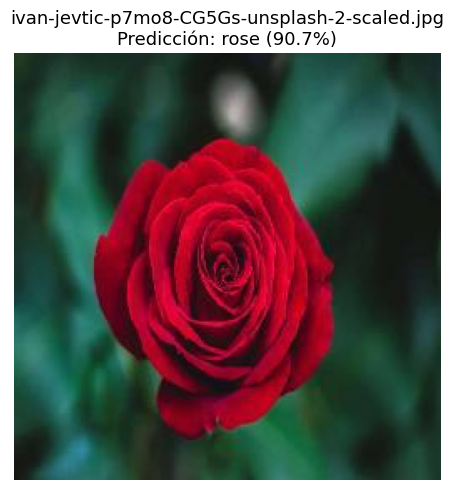

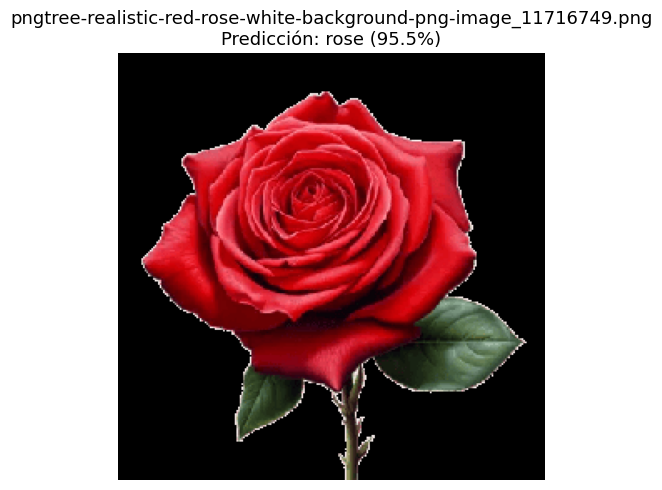

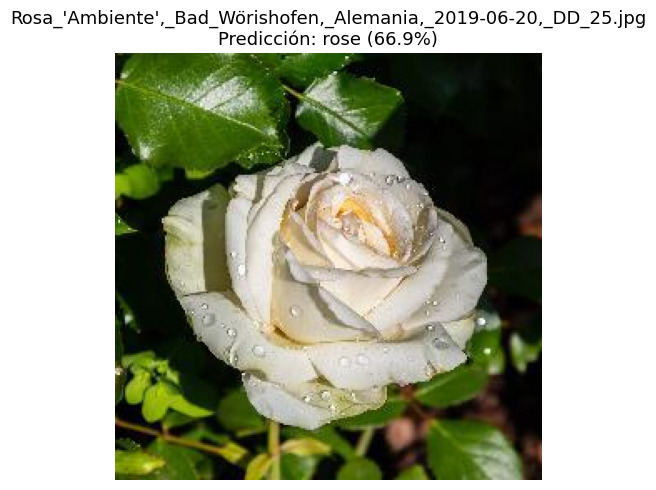

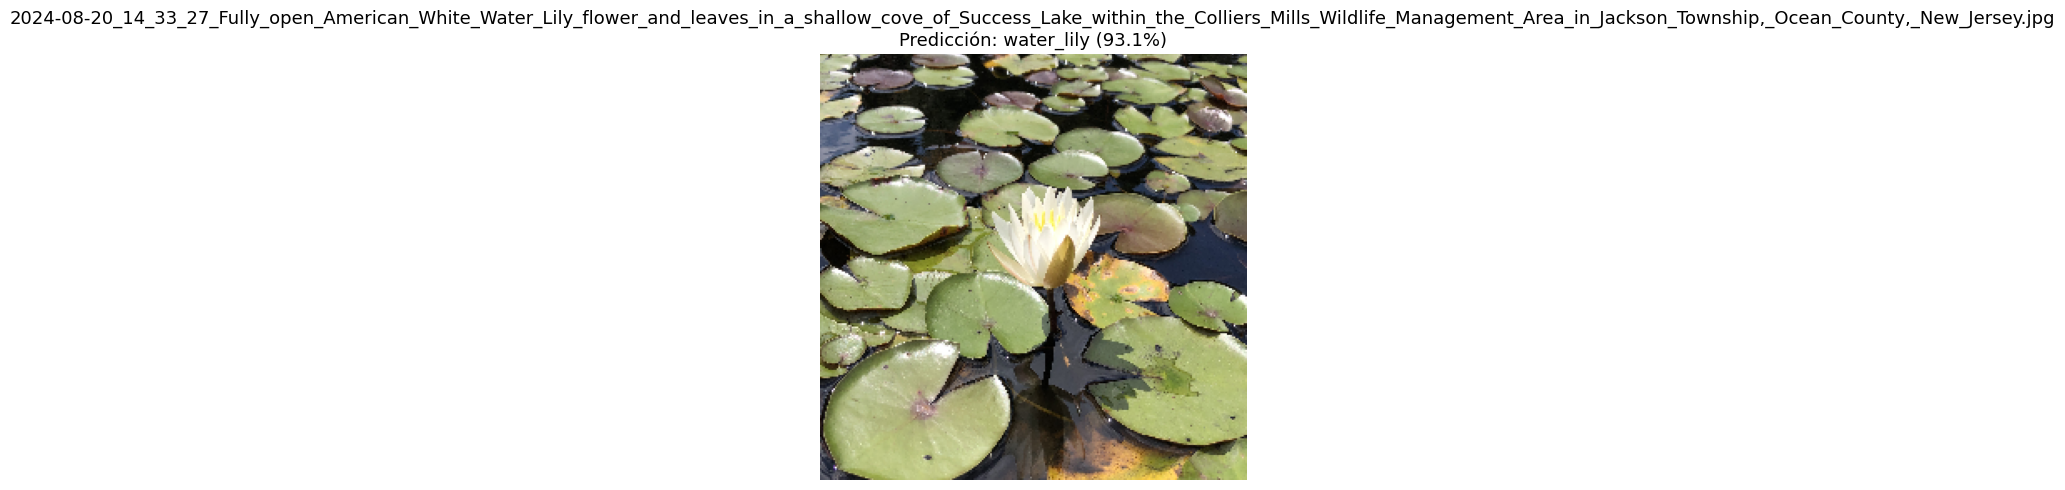

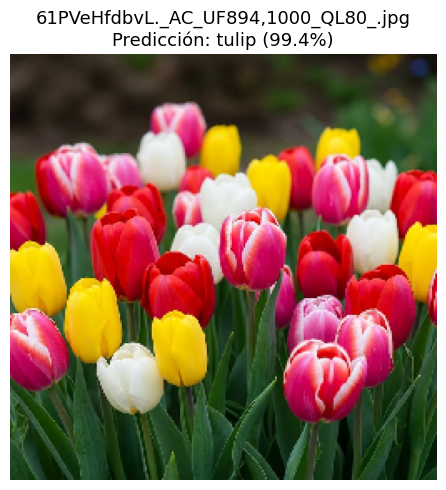

In [6]:

folder_path = "/content/drive/MyDrive/8vo/data/Flowers/usage"

print(f"Checking folder: {folder_path}")
if not os.path.exists(folder_path):
    print(f"Error: Folder does not exist at {folder_path}")
elif not os.path.isdir(folder_path):
    print(f"Error: Path is not a directory at {folder_path}")
else:
    all_files_in_folder = os.listdir(folder_path)
    print(f"All files found in {folder_path}: {all_files_in_folder}")
    predict_folder_like_testds(
        folder_path=folder_path,
        model=bettermodel,
        class_names=class_names
    )
